Sequential(
  (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (4): ReLU(inplace=True)
  (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU(inplace=True)
  (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): ReLU(inplace=True)
  (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
)

AlexNet has 5 conv layers

Layer            kernel    RF (px)
-----------------------------------
conv1_1              11         11
conv2_1               5         51
conv3_1               3         99
conv3_2               3       

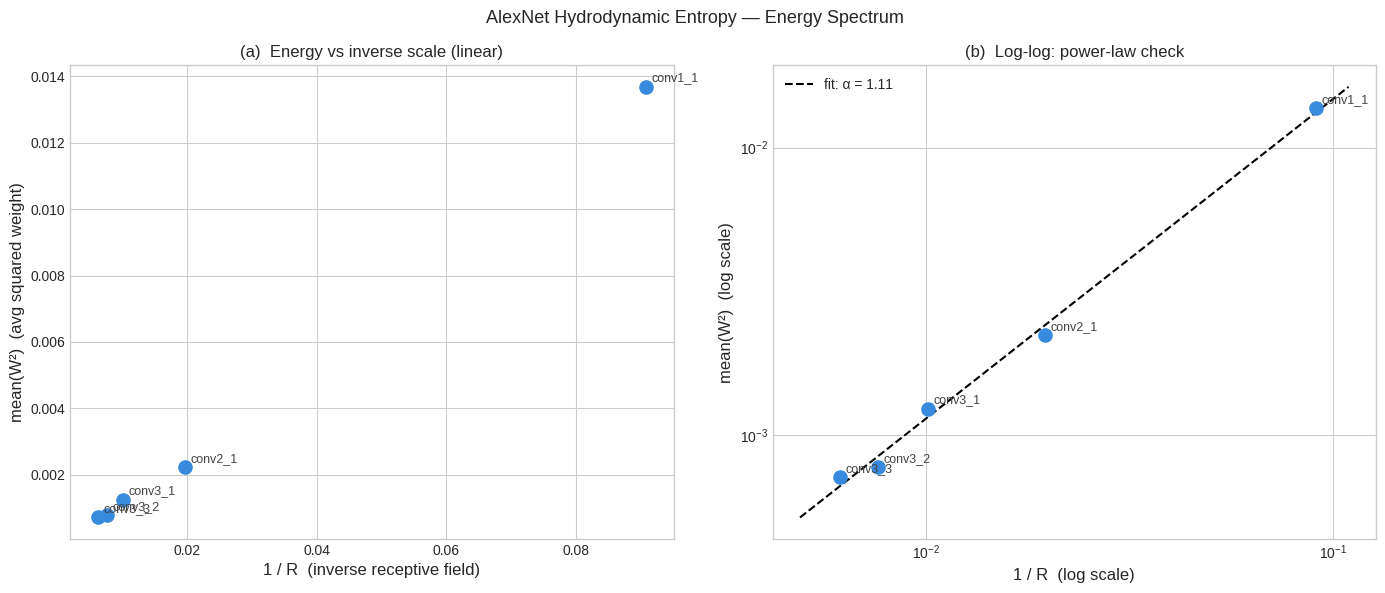

/tmp/ipykernel_5002/471998799.py:162: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig2.tight_layout()
/tmp/ipykernel_5002/471998799.py:163: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig2.savefig('alexnet_fig2_probability_contributions.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


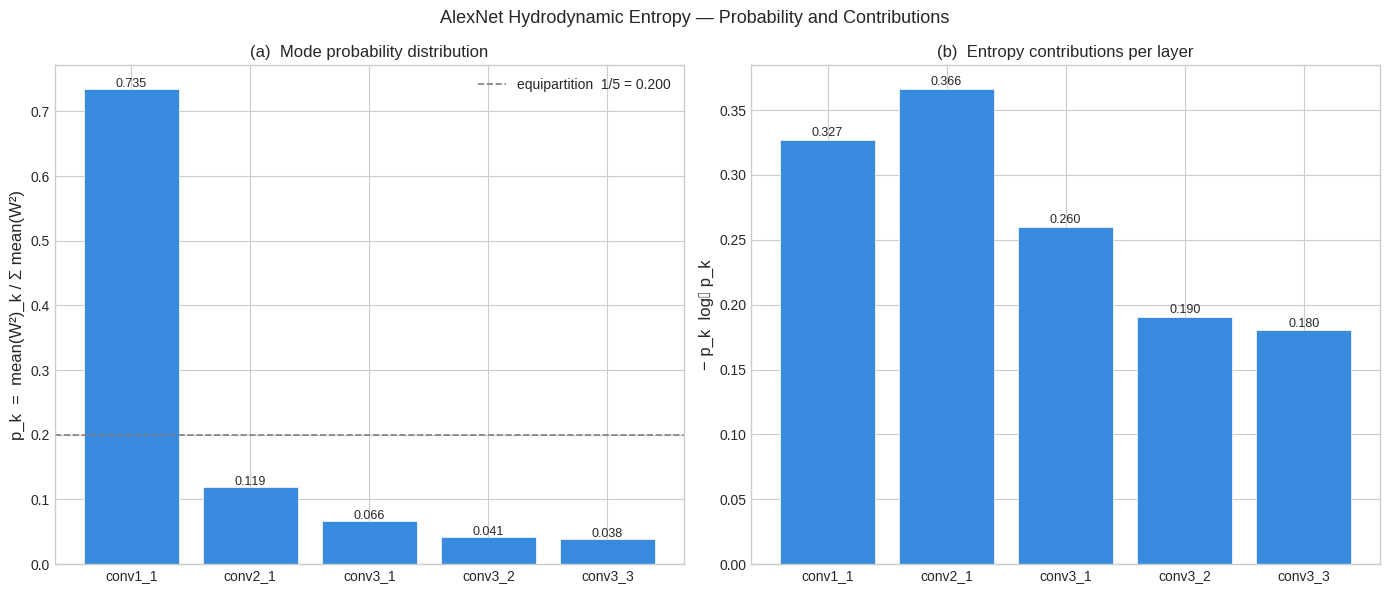

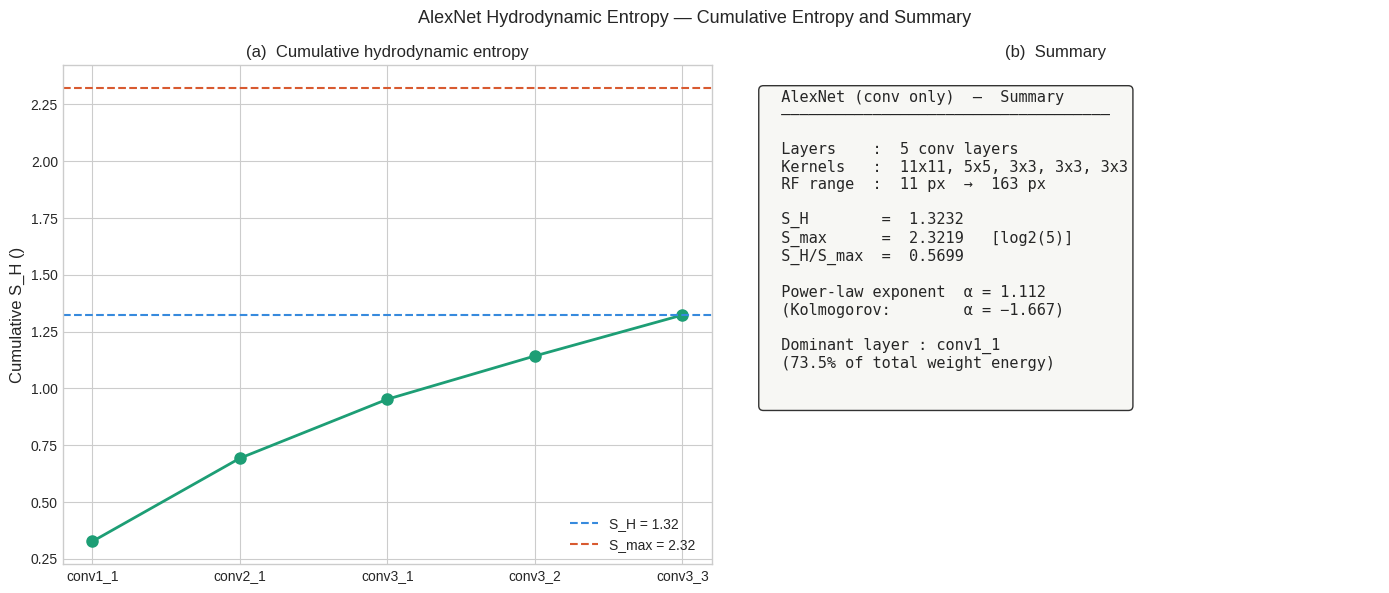

In [12]:
# ============================================================
# Hydrodynamic Entropy of AlexNet via Receptive Field Scale
#
# Analogy:
#   Receptive field R  <-->  length scale (1/k)
#   1/R                <-->  wavenumber k
#   mean(W^2) per layer <-->  modal energy E(k)
#   S_H = -sum(p log2 p) <--> hydrodynamic entropy
# ============================================================

import torch
import torchvision.models as models
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load pretrained AlexNet ────────────────────────────────
model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
model.eval()
print(model.features)

# ── 2. Compute receptive fields analytically ─────────────────
# Formula: R_n = R_{n-1} + (k-1) * cumulative_stride
# Pooling layers contribute to RF and update stride.

rf   = 1    # receptive field
jump = 1    # cumulative stride

names = []
R     = []

block         = 1
conv_in_block = 0

for layer in model.features:

    if isinstance(layer, nn.Conv2d):
        k  = layer.kernel_size[0]
        s  = layer.stride[0]
        rf   = rf + (k - 1) * jump
        jump = jump * s
        conv_in_block += 1
        names.append(f"conv{block}_{conv_in_block}")
        R.append(rf)

    elif isinstance(layer, nn.MaxPool2d):
        k  = layer.kernel_size if isinstance(layer.kernel_size, int) else layer.kernel_size[0]
        s  = layer.stride      if isinstance(layer.stride,      int) else layer.stride[0]
        rf   = rf + (k - 1) * jump
        jump = jump * s
        block        += 1
        conv_in_block = 0

R = np.array(R, dtype=float)

print(f"\nAlexNet has {len(names)} conv layers")
print(f"\n{'Layer':<14} {'kernel':>8} {'RF (px)':>10}")
print("-" * 35)
for n, r, layer in zip(
    names, R,
    [l for l in model.features if isinstance(l, nn.Conv2d)]
):
    print(f"{n:<14} {layer.kernel_size[0]:>8} {int(r):>10}")

# ── 3. Extract mean(W²) per conv layer ───────────────────────
def get_weight_norm_sq(model):
    norms = []
    for module in model.features:
        if isinstance(module, nn.Conv2d):
            w = module.weight.data
            norms.append(w.pow(2).mean().item())
    return np.array(norms)

E = get_weight_norm_sq(model)   # shape: (5,)

print(f"\nmean(W²) per layer: {np.round(E, 5)}")

# ── 4. Hydrodynamic entropy ───────────────────────────────────
p      = E / E.sum()
p_safe = np.where(p > 0, p, 1e-12)
S_H    = -np.sum(p_safe * np.log2(p_safe))
S_max  = np.log2(len(E))    # log2(5) ≈ 2.322

print(f"\nHydrodynamic Entropy  S_H       = {S_H:.4f} ")
print(f"Maximum entropy       S_max     = {S_max:.4f}   [log2({len(E)})]")
print(f"Normalized entropy    S_H/S_max = {S_H/S_max:.4f}")

# ── 5. Power-law fit ─────────────────────────────────────────
inv_R    = 1.0 / R
log_invR = np.log10(inv_R)
log_E    = np.log10(E)

alpha_fit, intercept = np.polyfit(log_invR, log_E, 1)
C = 10**intercept

print(f"\nPower-law fit:  mean(W²) ~ (1/R)^{alpha_fit:.3f}")
print(f"Kolmogorov:                   -5/3 = {-5/3:.3f}")

# ── shared plot setup ─────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')

contrib = -p_safe * np.log2(p_safe)
cum_S   = np.cumsum(contrib)
x_fit   = np.logspace(np.log10(inv_R.min()*0.8),
                      np.log10(inv_R.max()*1.2), 200)
y_fit   = C * x_fit**alpha_fit

# ── Figure 1: Energy spectrum ─────────────────────────────────
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig1.suptitle('AlexNet Hydrodynamic Entropy — Energy Spectrum',
              fontsize=13, fontweight='500')

for x, y, n in zip(inv_R, E, names):
    ax1.scatter(x, y, color='#378ADD', s=90, zorder=3)
    ax1.annotate(n, (x, y), fontsize=9, xytext=(4, 4),
                 textcoords='offset points', color='#444')
ax1.set_xlabel('1 / R  (inverse receptive field)', fontsize=12)
ax1.set_ylabel('mean(W²)  (avg squared weight)', fontsize=12)
ax1.set_title('(a)  Energy vs inverse scale (linear)', fontsize=12)

ax2.scatter(inv_R, E, color='#378ADD', s=90, zorder=3)
for x, y, n in zip(inv_R, E, names):
    ax2.annotate(n, (x, y), fontsize=9, xytext=(4, 4),
                 textcoords='offset points', color='#444')
ax2.plot(x_fit, y_fit, 'k--', lw=1.5, label=f'fit: α = {alpha_fit:.2f}')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('1 / R  (log scale)', fontsize=12)
ax2.set_ylabel('mean(W²)  (log scale)', fontsize=12)
ax2.set_title('(b)  Log-log: power-law check', fontsize=12)
ax2.legend(fontsize=10)

fig1.tight_layout()
fig1.savefig('alexnet_fig1_energy_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Probability and contributions ───────────────────
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle('AlexNet Hydrodynamic Entropy — Probability and Contributions',
              fontsize=13, fontweight='500')

ax3.bar(range(len(p)), p, color='#378ADD', edgecolor='white', linewidth=0.5)
ax3.set_xticks(range(len(p)))
ax3.set_xticklabels(names, rotation=0, fontsize=10)
ax3.set_ylabel('p_k  =  mean(W²)_k / Σ mean(W²)', fontsize=12)
ax3.set_title('(a)  Mode probability distribution', fontsize=12)
ax3.axhline(1/len(p), color='gray', ls='--', lw=1.2,
            label=f'equipartition  1/{len(p)} = {1/len(p):.3f}')
ax3.legend(fontsize=10)
for i, v in enumerate(p):
    ax3.text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9)

ax4.bar(range(len(contrib)), contrib, color='#378ADD',
        edgecolor='white', linewidth=0.5)
ax4.set_xticks(range(len(contrib)))
ax4.set_xticklabels(names, rotation=0, fontsize=10)
ax4.set_ylabel('− p_k  log₂ p_k', fontsize=12)
ax4.set_title('(b)  Entropy contributions per layer', fontsize=12)
for i, v in enumerate(contrib):
    ax4.text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9)

fig2.tight_layout()
fig2.savefig('alexnet_fig2_probability_contributions.png',
             dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Cumulative entropy + summary ────────────────────
fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(14, 6))
fig3.suptitle('AlexNet Hydrodynamic Entropy — Cumulative Entropy and Summary',
              fontsize=13, fontweight='500')

ax5.plot(range(len(cum_S)), cum_S, 'o-',
         color='#1D9E75', lw=2, ms=8)
ax5.axhline(S_H,   color='#378ADD', ls='--', lw=1.5,
            label=f'S_H = {S_H:.2f} ')
ax5.axhline(S_max, color='#D85A30', ls='--', lw=1.5,
            label=f'S_max = {S_max:.2f} ')
ax5.set_xticks(range(len(cum_S)))
ax5.set_xticklabels(names, rotation=0, fontsize=10)
ax5.set_ylabel('Cumulative S_H ()', fontsize=12)
ax5.set_title('(a)  Cumulative hydrodynamic entropy', fontsize=12)
ax5.legend(fontsize=10)

ax6.axis('off')
summary = (
    f"  AlexNet (conv only)  —  Summary\n"
    f"  {'─'*36}\n\n"
    f"  Layers    :  {len(names)} conv layers\n"
    f"  Kernels   :  11x11, 5x5, 3x3, 3x3, 3x3\n"
    f"  RF range  :  {int(R.min())} px  →  {int(R.max())} px\n\n"
    f"  S_H        =  {S_H:.4f} \n"
    f"  S_max      =  {S_max:.4f}   [log2({len(E)})]\n"
    f"  S_H/S_max  =  {S_H/S_max:.4f}\n\n"
    f"  Power-law exponent  α = {alpha_fit:.3f}\n"
    f"  (Kolmogorov:        α = −1.667)\n\n"
    f"  Dominant layer : {names[np.argmax(E)]}\n"
    f"  ({100*p.max():.1f}% of total weight energy)\n\n"
)
ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f5f5f2', alpha=0.8))
ax6.set_title('(b)  Summary', fontsize=12)

fig3.tight_layout()
fig3.savefig('alexnet_fig3_cumulative_summary.png',
             dpi=150, bbox_inches='tight')
plt.show()

Layer names       : ['conv1_1', 'conv1_2', 'conv2_1', 'conv2_2', 'conv3_1', 'conv3_2', 'conv3_3', 'conv4_1', 'conv4_2', 'conv4_3', 'conv5_1', 'conv5_2', 'conv5_3']
Receptive fields  : [  3   5  10  14  24  32  40  60  76  92 132 164 196]
mean(W^2) per layer: [0.063 0.003 0.002 0.001 0.001 0.001 0.001 0.    0.    0.    0.    0.
 0.   ]

Hydrodynamic Entropy  S_H   = 1.0666 
Maximum entropy       S_max = 3.7004   (log2(13))
Normalized entropy    S_H/S_max = 0.2882

Power-law fit (conv layers): E ~ (1/R)^1.052
  (Kolmogorov k^(-5/3) would give alpha = -5/3 ≈ -1.667)


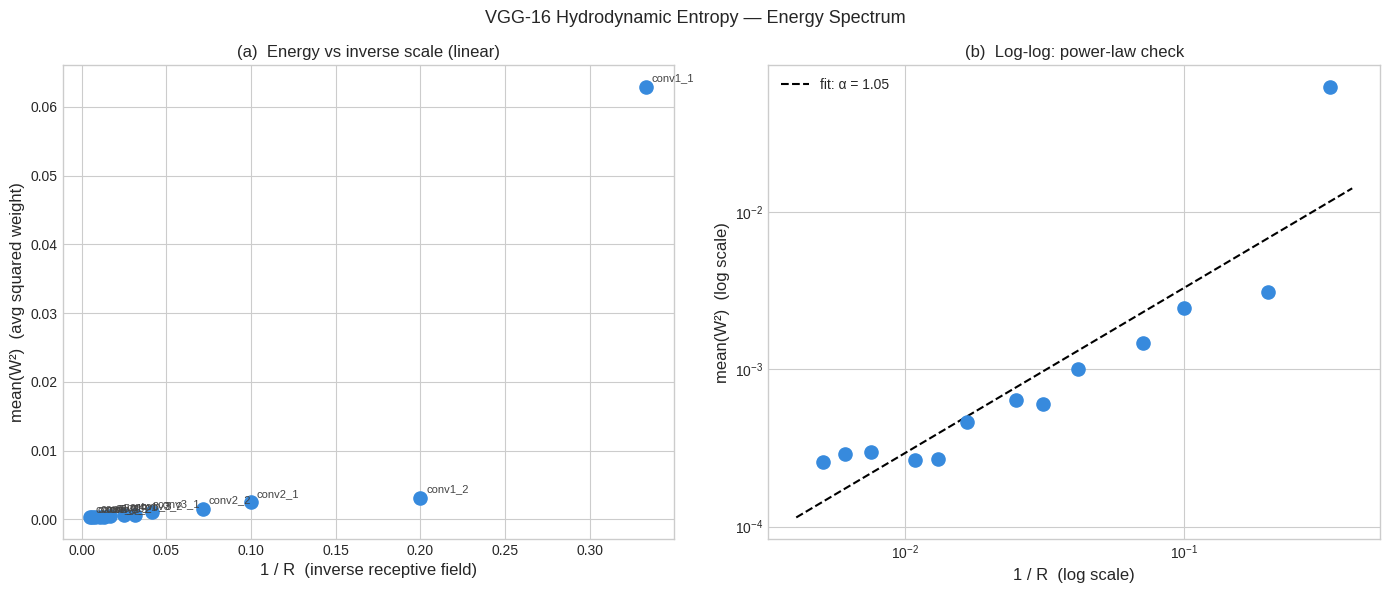

Saved: fig1_energy_spectrum.png


/tmp/ipykernel_5002/1979592048.py:176: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig2.tight_layout()
/tmp/ipykernel_5002/1979592048.py:177: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig2.savefig('fig2_probability_contributions.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


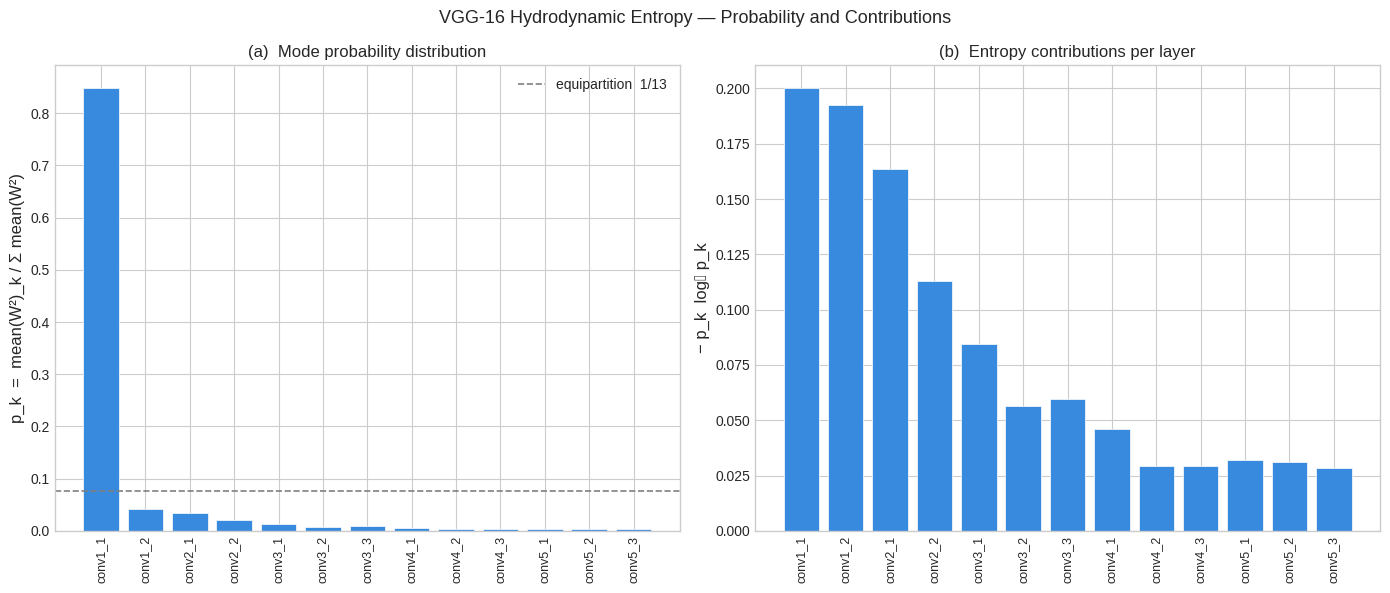

Saved: fig2_probability_contributions.png


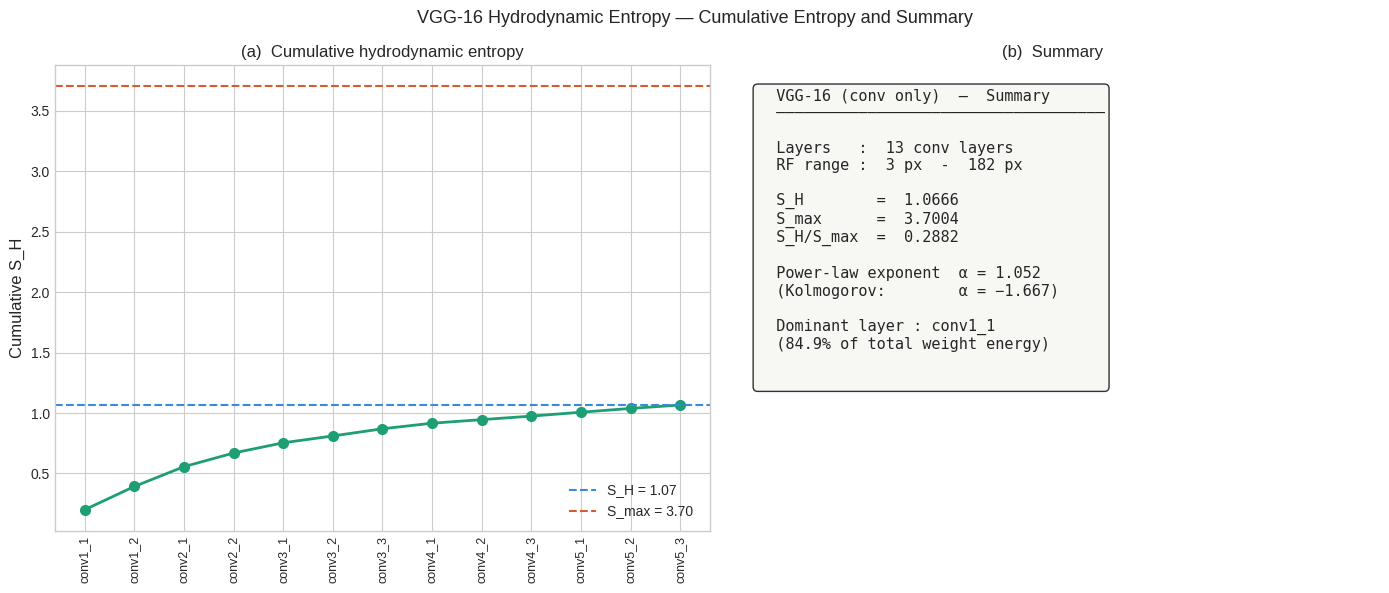

Saved: fig3_cumulative_summary.png


In [15]:
# ============================================================
# Hydrodynamic Entropy of VGG-16 via Receptive Field Scale
#
# Analogy:
#   Receptive field R  <-->  length scale (1/k)
#   1/R                <-->  wavenumber k
#   sum(W^2) per layer <-->  modal energy E(k)
#   S_H = -sum(p log2 p) <--> hydrodynamic entropy
# ============================================================

# 0. Install
# !pip install torch torchvision matplotlib numpy --quiet

import torch
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt

#  1. Load pretrained VGG-16
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()

# 2. Define receptive field sizes for VGG-16 (conv only)
# Receptive field R after each conv layer (standard formula,
# stride-1 convs + 2x2 maxpool with stride 2 after groups).
# Computed analytically for VGG-16 on 224x224 input.
#
# Formula: R_l = R_{l-1} + (k-1) * prod(strides before l)
# After each maxpool, effective stride doubles.
# FC layers excluded: no spatial structure, no RF growth.

import torch.nn as nn

rf = 1       # initial receptive field
jump = 1     # effective stride

names = []
R = []

block = 1
conv_in_block = 0

for layer in model.features:

    # ---- Conv layers ----
    if isinstance(layer, nn.Conv2d):
        k = layer.kernel_size[0]
        s = layer.stride[0]

        rf = rf + (k - 1) * jump
        jump = jump * s

        conv_in_block += 1
        name = f"conv{block}_{conv_in_block}"

        names.append(name)
        R.append(rf)

    # ---- MaxPool layers ----
    elif isinstance(layer, nn.MaxPool2d):
        k = layer.kernel_size if isinstance(layer.kernel_size, int) else layer.kernel_size[0]
        s = layer.stride if isinstance(layer.stride, int) else layer.stride[0]

        rf = rf + (k - 1) * jump
        jump = jump * s

        block += 1
        conv_in_block = 0

# convert to numpy (same as before)
R = np.array(R, dtype=float)

# ── 3. Extract mean(W^2) = average squared weight per element ──────
def get_weight_norm_sq(model):
    """
    Walk VGG-16 features block (conv layers only).
    FC layers excluded: they lack spatial structure and
    receptive field growth, breaking the scale analogy.
    """
    norms = []
    for module in model.features:
        if isinstance(module, torch.nn.Conv2d):
            w = module.weight.data
            norms.append(w.pow(2).mean().item())
    return np.array(norms)

E = get_weight_norm_sq(model)   # shape: (13,)
print("Layer names       :", names)
print("Receptive fields  :", R.astype(int))
print("mean(W^2) per layer:", np.round(E, 3))

# ── 4. Compute hydrodynamic entropy ─────────────────────────
# p_k = E_k / sum(E_k)    [probability of each "mode"]
# S_H = -sum(p_k * log2(p_k))
# S_max = log2(N_layers)  [equipartition baseline]

p   = E / E.sum()                          # probabilities
# guard log2(0)
p_safe = np.where(p > 0, p, 1e-12)
S_H    = -np.sum(p_safe * np.log2(p_safe))
S_max  = np.log2(len(E))                   # maximum possible HE

print(f"\nHydrodynamic Entropy  S_H   = {S_H:.4f} ")
print(f"Maximum entropy       S_max = {S_max:.4f}   (log2({len(E)}))")
print(f"Normalized entropy    S_H/S_max = {S_H/S_max:.4f}")

# ── 5. Power-law fit  E ~ (1/R)^alpha in log-log ─────────────
# In turbulence: E(k) ~ k^(-5/3), i.e. E ~ (1/R)^(-5/3)
# Here: fit E ~ (1/R)^alpha across all conv layers
# Negative alpha => energy grows at larger scales (larger R),
# analogous to the turbulence cascade.

log_invR = np.log10(1.0 / R)
log_E    = np.log10(E)

alpha_fit, intercept = np.polyfit(log_invR, log_E, 1)
print(f"\nPower-law fit (conv layers): E ~ (1/R)^{alpha_fit:.3f}")
print(f"  (Kolmogorov k^(-5/3) would give alpha = -5/3 ≈ -1.667)")

# ── 6. Plots — 2 panels per figure ───────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
inv_R  = 1.0 / R
contrib = -p_safe * np.log2(p_safe)
cum_S   = np.cumsum(contrib)
x_fit   = np.logspace(np.log10(inv_R.min()*0.8),
                      np.log10(inv_R.max()*1.2), 100)
y_fit   = 10**intercept * x_fit**alpha_fit

# ── Figure 1: Energy spectrum ─────────────────────────────────
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig1.suptitle('VGG-16 Hydrodynamic Entropy — Energy Spectrum',
              fontsize=13, fontweight='500')

for x, y, n in zip(inv_R, E, names):
    ax1.scatter(x, y, color='#378ADD', s=90, zorder=3)
    ax1.annotate(n, (x, y), fontsize=8, xytext=(4, 4),
                 textcoords='offset points', color='#444')
ax1.set_xlabel('1 / R  (inverse receptive field)', fontsize=12)
ax1.set_ylabel('mean(W²)  (avg squared weight)', fontsize=12)
ax1.set_title('(a)  Energy vs inverse scale (linear)', fontsize=12)

ax2.scatter(inv_R, E, color='#378ADD', s=90, zorder=3)
ax2.plot(x_fit, y_fit, 'k--', lw=1.5, label=f'fit: α = {alpha_fit:.2f}')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('1 / R  (log scale)', fontsize=12)
ax2.set_ylabel('mean(W²)  (log scale)', fontsize=12)
ax2.set_title('(b)  Log-log: power-law check', fontsize=12)
ax2.legend(fontsize=10)

fig1.tight_layout()
fig1.savefig('fig1_energy_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_energy_spectrum.png")

# ── Figure 2: Probability and entropy contributions ───────────
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle('VGG-16 Hydrodynamic Entropy — Probability and Contributions',
              fontsize=13, fontweight='500')

ax3.bar(range(len(p)), p, color='#378ADD', edgecolor='white', linewidth=0.5)
ax3.set_xticks(range(len(p)))
ax3.set_xticklabels(names, rotation=90, fontsize=9)
ax3.set_ylabel('p_k  =  mean(W²)_k / Σ mean(W²)', fontsize=12)
ax3.set_title('(a)  Mode probability distribution', fontsize=12)
ax3.axhline(1/len(p), color='gray', ls='--', lw=1.2,
            label=f'equipartition  1/{len(p)}')
ax3.legend(fontsize=10)

ax4.bar(range(len(contrib)), contrib, color='#378ADD',
        edgecolor='white', linewidth=0.5)
ax4.set_xticks(range(len(contrib)))
ax4.set_xticklabels(names, rotation=90, fontsize=9)
ax4.set_ylabel('− p_k  log₂ p_k', fontsize=12)
ax4.set_title('(b)  Entropy contributions per layer', fontsize=12)

fig2.tight_layout()
fig2.savefig('fig2_probability_contributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_probability_contributions.png")

# ── Figure 3: Cumulative entropy + summary ────────────────────
fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(14, 6))
fig3.suptitle('VGG-16 Hydrodynamic Entropy — Cumulative Entropy and Summary',
              fontsize=13, fontweight='500')

ax5.plot(range(len(cum_S)), cum_S, 'o-', color='#1D9E75', lw=2, ms=7)
ax5.axhline(S_H,   color='#378ADD', ls='--', lw=1.5,
            label=f'S_H = {S_H:.2f} ')
ax5.axhline(S_max, color='#D85A30', ls='--', lw=1.5,
            label=f'S_max = {S_max:.2f} ')
ax5.set_xticks(range(len(cum_S)))
ax5.set_xticklabels(names, rotation=90, fontsize=9)
ax5.set_ylabel('Cumulative S_H', fontsize=12)
ax5.set_title('(a)  Cumulative hydrodynamic entropy', fontsize=12)
ax5.legend(fontsize=10)

ax6.axis('off')
summary = (
    f"  VGG-16 (conv only)  —  Summary\n"
    f"  {'─'*36}\n\n"
    f"  Layers   :  13 conv layers\n"
    f"  RF range :  3 px  -  182 px\n\n"
    f"  S_H        =  {S_H:.4f} \n"
    f"  S_max      =  {S_max:.4f} \n"
    f"  S_H/S_max  =  {S_H/S_max:.4f}\n\n"
    f"  Power-law exponent  α = {alpha_fit:.3f}\n"
    f"  (Kolmogorov:        α = −1.667)\n\n"
    f"  Dominant layer : {names[np.argmax(E)]}\n"
    f"  ({100*p.max():.1f}% of total weight energy)\n\n"

)
ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f5f5f2', alpha=0.8))
ax6.set_title('(b)  Summary', fontsize=12)

fig3.tight_layout()
fig3.savefig('fig3_cumulative_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig3_cumulative_summary.png")

VGG-19 has 16 conv layers

Layer             RF (px)
--------------------------
conv1_1                 3
conv1_2                 5
conv2_1                10
conv2_2                14
conv3_1                24
conv3_2                32
conv3_3                40
conv3_4                48
conv4_1                68
conv4_2                84
conv4_3               100
conv4_4               116
conv5_1               156
conv5_2               188
conv5_3               220
conv5_4               252

mean(W²) per layer: [0.0644 0.0031 0.0024 0.0015 0.0009 0.0005 0.0005 0.0005 0.0004 0.0002
 0.0002 0.0002 0.0003 0.0003 0.0002 0.0002]

Hydrodynamic Entropy  S_H       = 1.1028 
Maximum entropy       S_max     = 4.0000   [log2(16)]
Normalized entropy    S_H/S_max = 0.2757

Power-law fit:  mean(W²) ~ (1/R)^1.010
Kolmogorov reference:    alpha = -5/3 = -1.667


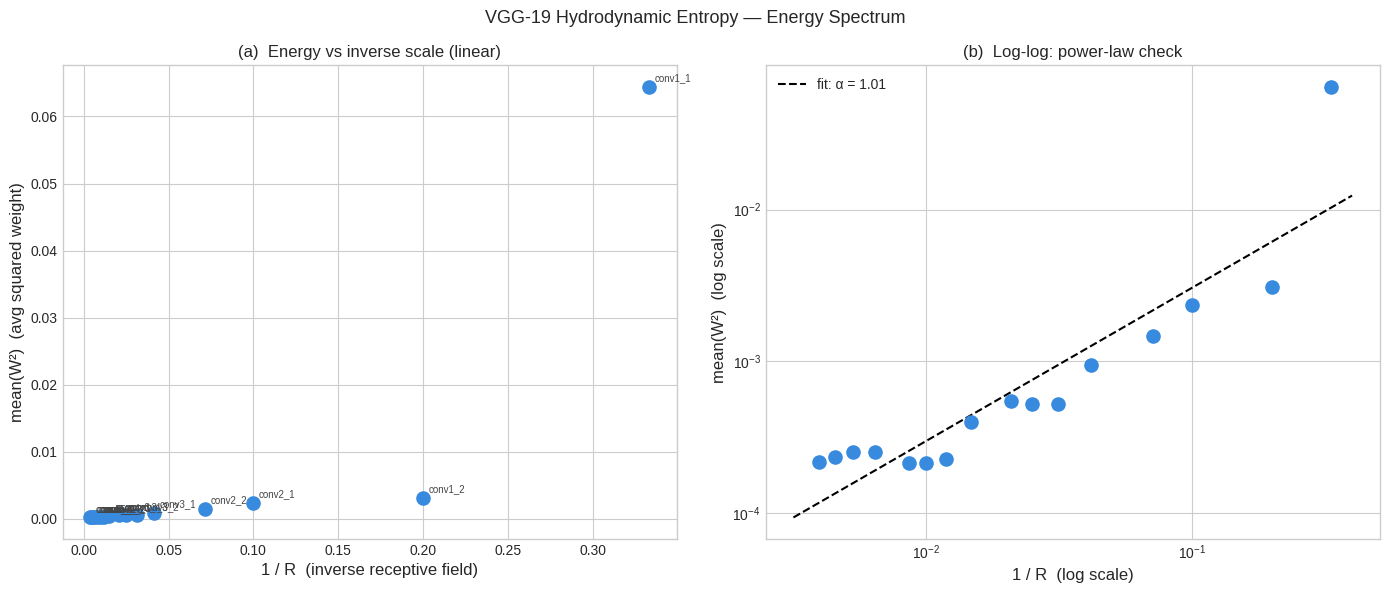

/tmp/ipykernel_5002/2734310838.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig2.tight_layout()
/tmp/ipykernel_5002/2734310838.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig2.savefig('vgg19_fig2_probability_contributions.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


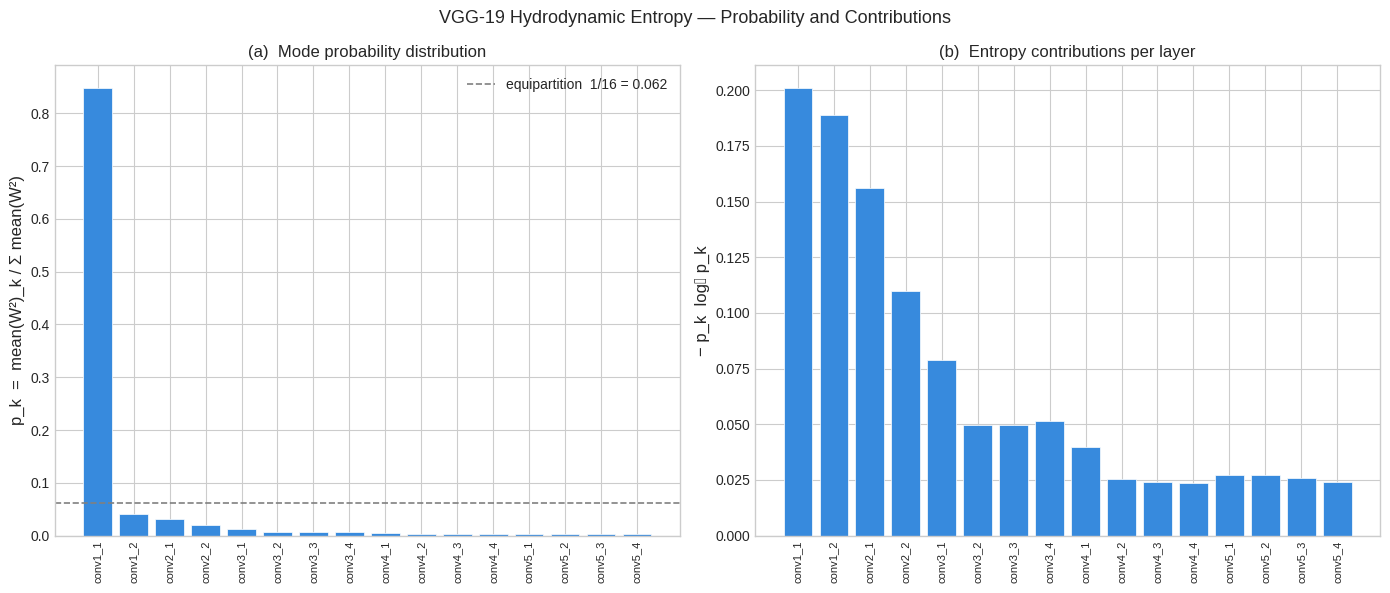

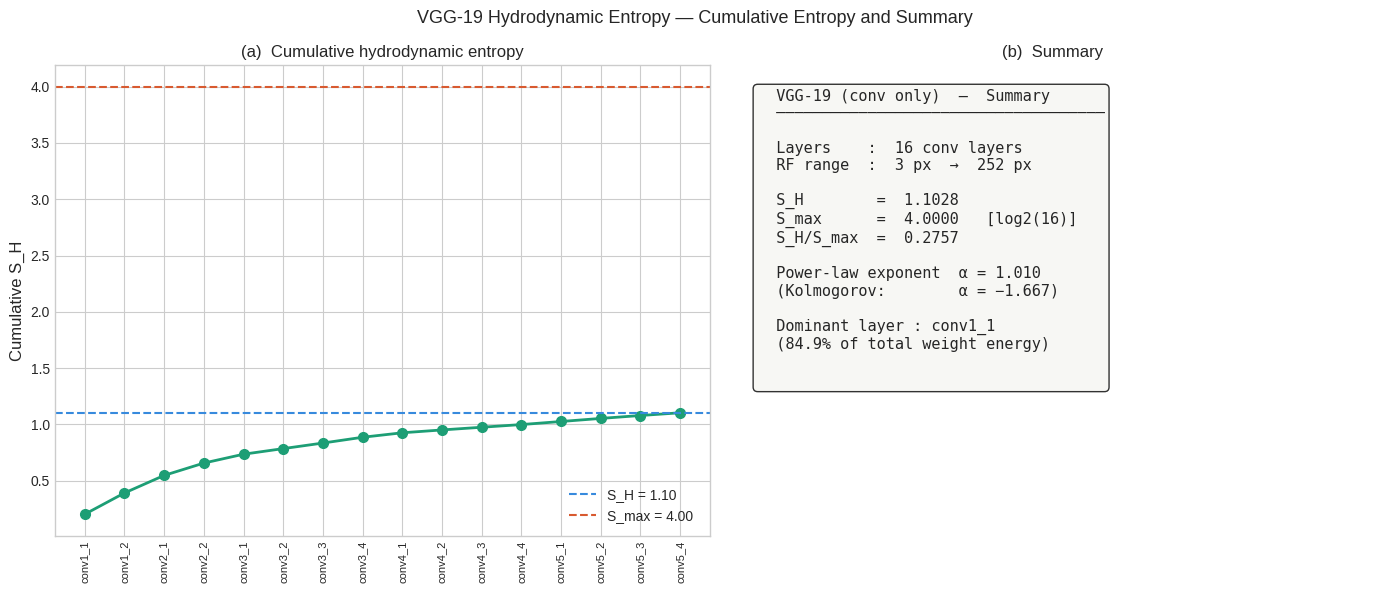

In [17]:
# ============================================================
# Hydrodynamic Entropy of VGG-19 via Receptive Field Scale
#
# Analogy:
#   Receptive field R  <-->  length scale (1/k)
#   1/R                <-->  wavenumber k
#   mean(W^2) per layer <-->  modal energy E(k)
#   S_H = -sum(p log2 p) <--> hydrodynamic entropy
# ============================================================

import torch
import torchvision.models as models
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load pretrained VGG-19 ────────────────────────────────
model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
model.eval()

# ── 2. Compute receptive fields analytically ─────────────────
# Formula: R_n = R_{n-1} + (k-1) * cumulative_stride
# Pooling layers update stride but are included in RF growth.

rf   = 1    # receptive field
jump = 1    # cumulative stride

names = []
R     = []

block          = 1
conv_in_block  = 0

for layer in model.features:

    if isinstance(layer, nn.Conv2d):
        k  = layer.kernel_size[0]
        s  = layer.stride[0]
        rf = rf + (k - 1) * jump
        jump = jump * s
        conv_in_block += 1
        names.append(f"conv{block}_{conv_in_block}")
        R.append(rf)

    elif isinstance(layer, nn.MaxPool2d):
        k  = layer.kernel_size if isinstance(layer.kernel_size, int) else layer.kernel_size[0]
        s  = layer.stride      if isinstance(layer.stride,      int) else layer.stride[0]
        rf   = rf + (k - 1) * jump
        jump = jump * s
        block         += 1
        conv_in_block  = 0

R = np.array(R, dtype=float)

print(f"VGG-19 has {len(names)} conv layers")
print(f"\n{'Layer':<14} {'RF (px)':>10}")
print("-" * 26)
for n, r in zip(names, R):
    print(f"{n:<14} {int(r):>10}")

# ── 3. Extract mean(W²) per conv layer ───────────────────────
def get_weight_norm_sq(model):
    norms = []
    for module in model.features:
        if isinstance(module, nn.Conv2d):
            w = module.weight.data
            norms.append(w.pow(2).mean().item())
    return np.array(norms)

E = get_weight_norm_sq(model)   # shape: (16,)

print(f"\nmean(W²) per layer: {np.round(E, 4)}")

# ── 4. Hydrodynamic entropy ───────────────────────────────────
p      = E / E.sum()
p_safe = np.where(p > 0, p, 1e-12)
S_H    = -np.sum(p_safe * np.log2(p_safe))
S_max  = np.log2(len(E))    # log2(16) = 4.0

print(f"\nHydrodynamic Entropy  S_H       = {S_H:.4f} ")
print(f"Maximum entropy       S_max     = {S_max:.4f}   [log2({len(E)})]")
print(f"Normalized entropy    S_H/S_max = {S_H/S_max:.4f}")

# ── 5. Power-law fit ─────────────────────────────────────────
inv_R    = 1.0 / R
log_invR = np.log10(inv_R)
log_E    = np.log10(E)

alpha_fit, intercept = np.polyfit(log_invR, log_E, 1)
C = 10**intercept

print(f"\nPower-law fit:  mean(W²) ~ (1/R)^{alpha_fit:.3f}")
print(f"Kolmogorov reference:    alpha = -5/3 = {-5/3:.3f}")

# ── shared plot setup ─────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')

contrib = -p_safe * np.log2(p_safe)
cum_S   = np.cumsum(contrib)
x_fit   = np.logspace(np.log10(inv_R.min()*0.8),
                      np.log10(inv_R.max()*1.2), 200)
y_fit   = C * x_fit**alpha_fit

# ── Figure 1: Energy spectrum ─────────────────────────────────
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig1.suptitle('VGG-19 Hydrodynamic Entropy — Energy Spectrum',
              fontsize=13, fontweight='500')

for x, y, n in zip(inv_R, E, names):
    ax1.scatter(x, y, color='#378ADD', s=90, zorder=3)
    ax1.annotate(n, (x, y), fontsize=7, xytext=(4, 4),
                 textcoords='offset points', color='#444')
ax1.set_xlabel('1 / R  (inverse receptive field)', fontsize=12)
ax1.set_ylabel('mean(W²)  (avg squared weight)', fontsize=12)
ax1.set_title('(a)  Energy vs inverse scale (linear)', fontsize=12)

ax2.scatter(inv_R, E, color='#378ADD', s=90, zorder=3)
ax2.plot(x_fit, y_fit, 'k--', lw=1.5, label=f'fit: α = {alpha_fit:.2f}')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('1 / R  (log scale)', fontsize=12)
ax2.set_ylabel('mean(W²)  (log scale)', fontsize=12)
ax2.set_title('(b)  Log-log: power-law check', fontsize=12)
ax2.legend(fontsize=10)

fig1.tight_layout()
fig1.savefig('vgg19_fig1_energy_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Probability and entropy contributions ───────────
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle('VGG-19 Hydrodynamic Entropy — Probability and Contributions',
              fontsize=13, fontweight='500')

ax3.bar(range(len(p)), p, color='#378ADD', edgecolor='white', linewidth=0.5)
ax3.set_xticks(range(len(p)))
ax3.set_xticklabels(names, rotation=90, fontsize=8)
ax3.set_ylabel('p_k  =  mean(W²)_k / Σ mean(W²)', fontsize=12)
ax3.set_title('(a)  Mode probability distribution', fontsize=12)
ax3.axhline(1/len(p), color='gray', ls='--', lw=1.2,
            label=f'equipartition  1/{len(p)} = {1/len(p):.3f}')
ax3.legend(fontsize=10)

ax4.bar(range(len(contrib)), contrib, color='#378ADD',
        edgecolor='white', linewidth=0.5)
ax4.set_xticks(range(len(contrib)))
ax4.set_xticklabels(names, rotation=90, fontsize=8)
ax4.set_ylabel('− p_k  log₂ p_k', fontsize=12)
ax4.set_title('(b)  Entropy contributions per layer', fontsize=12)

fig2.tight_layout()
fig2.savefig('vgg19_fig2_probability_contributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Cumulative entropy + summary ────────────────────
fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(14, 6))
fig3.suptitle('VGG-19 Hydrodynamic Entropy — Cumulative Entropy and Summary',
              fontsize=13, fontweight='500')

ax5.plot(range(len(cum_S)), cum_S, 'o-', color='#1D9E75', lw=2, ms=7)
ax5.axhline(S_H,   color='#378ADD', ls='--', lw=1.5,
            label=f'S_H = {S_H:.2f} ')
ax5.axhline(S_max, color='#D85A30', ls='--', lw=1.5,
            label=f'S_max = {S_max:.2f} ')
ax5.set_xticks(range(len(cum_S)))
ax5.set_xticklabels(names, rotation=90, fontsize=8)
ax5.set_ylabel('Cumulative S_H', fontsize=12)
ax5.set_title('(a)  Cumulative hydrodynamic entropy', fontsize=12)
ax5.legend(fontsize=10)

ax6.axis('off')
summary = (
    f"  VGG-19 (conv only)  —  Summary\n"
    f"  {'─'*36}\n\n"
    f"  Layers    :  {len(names)} conv layers\n"
    f"  RF range  :  {int(R.min())} px  →  {int(R.max())} px\n\n"
    f"  S_H        =  {S_H:.4f} \n"
    f"  S_max      =  {S_max:.4f}   [log2({len(E)})]\n"
    f"  S_H/S_max  =  {S_H/S_max:.4f}\n\n"
    f"  Power-law exponent  α = {alpha_fit:.3f}\n"
    f"  (Kolmogorov:        α = −1.667)\n\n"
    f"  Dominant layer : {names[np.argmax(E)]}\n"
    f"  ({100*p.max():.1f}% of total weight energy)\n\n"
)
ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f5f5f2', alpha=0.8))
ax6.set_title('(b)  Summary', fontsize=12)

fig3.tight_layout()
fig3.savefig('vgg19_fig3_cumulative_summary.png', dpi=150, bbox_inches='tight')
plt.show()